# VIP Digit Recognition Web App (MNIST)

## Group Details
- Group: Group 2
- Course: CDS6334 Visual Information Processing (VIP)
- Project Title: Handwritten Digit Recognition using VIP Techniques (No Deep Learning)

## Team Members 
1. Venggadanaathan A/L K.Salvam (1231303562)
2. Yasha Durgashine (1221308310)
3. Pavithira Saravanan (1211110400)
4. Tharraniah Tamilwanan (1211111799)

## Project Objective
Build a user-friendly web application that can recognize **single-digit and multi-digit** handwritten numbers from an uploaded image using **only Visual Information Processing techniques**, not deep learning.

## Dataset
- MNIST handwritten digit dataset (28×28 grayscale)
- Files used: `train-images.idx3-ubyte`, `train-labels.idx1-ubyte`, `t10k-images.idx3-ubyte`, `t10k-labels.idx1-ubyte`

## Notebook Purpose
This notebook:
1. Loads MNIST from local IDX (Kaggle download)
2. Applies VIP preprocessing (normalization)
3. Builds **K=8 prototype templates** per digit
4. Evaluates accuracy
5. Saves prototypes for Streamlit app (`results/prototypes_K8.npz`)


## 1. Environment Setup
This section imports required libraries and defines project folders.


In [65]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import confusion_matrix


In [66]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))  # project root
DATA_DIR = os.path.join(BASE_DIR, "data", "mnist")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print("CWD:", os.getcwd())
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

if os.path.exists(DATA_DIR):
    print("MNIST files (sample):", os.listdir(DATA_DIR)[:10])
else:
    print("❌ DATA_DIR not found. Put MNIST IDX files into:", DATA_DIR)


CWD: C:\Users\vengg\Desktop\vip-digit-recognition\notebooks
BASE_DIR: C:\Users\vengg\Desktop\vip-digit-recognition
DATA_DIR: C:\Users\vengg\Desktop\vip-digit-recognition\data\mnist
RESULTS_DIR: C:\Users\vengg\Desktop\vip-digit-recognition\results
MNIST files (sample): ['t10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte', 'train-images.idx3-ubyte', 'train-labels.idx1-ubyte']


## 2. Dataset Loading (MNIST IDX Format)

The MNIST dataset is provided in IDX binary format.  
This section defines helper functions to read the IDX image and label files
and loads the training and testing datasets from disk.


IDX FILE READERS

In [69]:
def load_idx_images(path):
    """
    Load images from an IDX3 ubyte file.
    Returns array of shape (N, H, W).
    """
    with open(path, "rb") as f:
        magic = int.from_bytes(f.read(4), "big")
        num = int.from_bytes(f.read(4), "big")
        rows = int.from_bytes(f.read(4), "big")
        cols = int.from_bytes(f.read(4), "big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(num, rows, cols)


def load_idx_labels(path):
    """
    Load labels from an IDX1 ubyte file.
    Returns array of shape (N,).
    """
    with open(path, "rb") as f:
        magic = int.from_bytes(f.read(4), "big")
        num = int.from_bytes(f.read(4), "big")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


Load MNIST Train/Test Sets

In [71]:
train_images = load_idx_images(os.path.join(DATA_DIR, "train-images.idx3-ubyte"))
train_labels = load_idx_labels(os.path.join(DATA_DIR, "train-labels.idx1-ubyte"))

test_images = load_idx_images(os.path.join(DATA_DIR, "t10k-images.idx3-ubyte"))
test_labels = load_idx_labels(os.path.join(DATA_DIR, "t10k-labels.idx1-ubyte"))

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)




Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## 3. Dataset Sanity Check

We visualise a few training samples to confirm that the MNIST images
and labels are loaded correctly.


Visualise Sample Digits

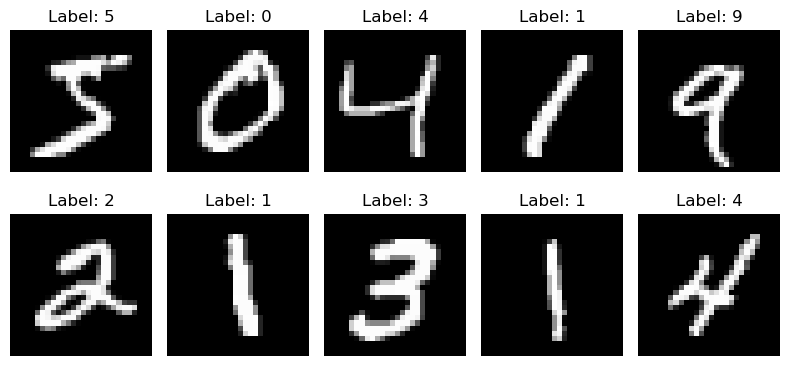

In [74]:
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()



## 4. VIP Preprocessing (MNIST-style Normalization)

To improve recognition accuracy, we normalize each digit image into a consistent form.
This uses only VIP techniques:

- Gaussian smoothing
- Otsu thresholding
- Morphological closing (repair broken strokes)
- Bounding box cropping
- Size normalization to 20×20 inside a 28×28 canvas
- Centroid alignment (center of mass)

This reduces variations in position, size, and stroke noise.


Convert to Float [0,1]

In [77]:
X_train = train_images.astype(np.float32) / 255.0
y_train = train_labels.astype(int)

X_test = test_images.astype(np.float32) / 255.0
y_test = test_labels.astype(int)

print("Pixel range:", X_train.min(), "to", X_train.max())


Pixel range: 0.0 to 1.0


VIP Helper Functions

In [79]:
def gaussian_blur(img, ksize=3):
    img_u8 = (img * 255).astype(np.uint8)
    out = cv2.GaussianBlur(img_u8, (ksize, ksize), sigmaX=0)
    return out.astype(np.float32) / 255.0

def otsu_binarize_u8(img_float01):
    img_u8 = (img_float01 * 255).astype(np.uint8)
    _, bw = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return bw

def morph_close_u8(bw_u8, k=2):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    return cv2.morphologyEx(bw_u8, cv2.MORPH_CLOSE, kernel)


MNIST-Style Normalization Function

In [81]:
def mnist_style_normalize(img_28, blur_ksize=3, morph_k=2):
    """
    Input:  28x28 float image in [0,1], digit bright on dark.
    Output: 28x28 float image in [0,1] after VIP normalization.
    """
    sm = gaussian_blur(img_28, ksize=blur_ksize)
    bw = otsu_binarize_u8(sm)
    bw = morph_close_u8(bw, k=morph_k)

    ys, xs = np.where(bw > 0)
    if len(xs) == 0 or len(ys) == 0:
        return img_28

    # Bounding box crop
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    digit = bw[y0:y1+1, x0:x1+1]

    # Resize digit to fit within 20x20
    h, w = digit.shape
    scale = 20.0 / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    digit = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Place on 28x28 canvas
    canvas = np.zeros((28, 28), dtype=np.uint8)
    y_off = (28 - new_h) // 2
    x_off = (28 - new_w) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = digit

    # Centroid alignment
    M = cv2.moments(canvas)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        shift_x = 14 - cx
        shift_y = 14 - cy
        T = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        canvas = cv2.warpAffine(canvas, T, (28, 28), borderValue=0)

    return (canvas / 255.0).astype(np.float32)



Apply Normalization to Train/Test

In [83]:
X_train_norm = np.array([mnist_style_normalize(img) for img in X_train], dtype=np.float32)
X_test_norm  = np.array([mnist_style_normalize(img) for img in X_test], dtype=np.float32)

print("Normalized train:", X_train_norm.shape)
print("Normalized test :", X_test_norm.shape)



Normalized train: (60000, 28, 28)
Normalized test : (10000, 28, 28)


Before/After Visualisation

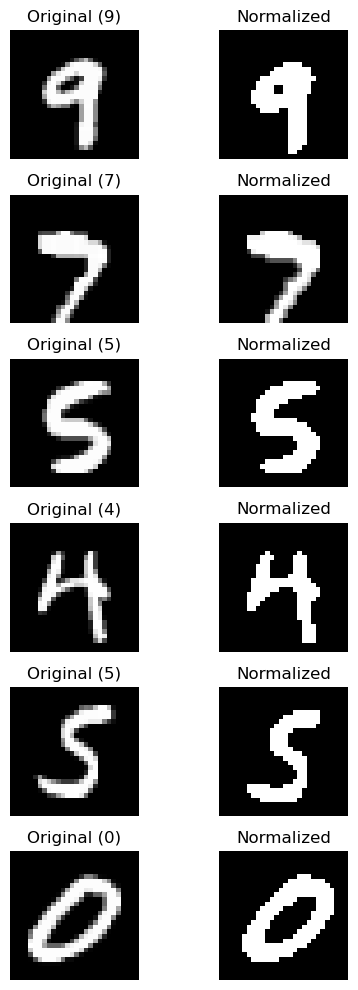

In [85]:
idxs = np.random.choice(len(X_train), 6, replace=False)

fig, axes = plt.subplots(6, 2, figsize=(5, 10))
for r, idx in enumerate(idxs):
    axes[r, 0].imshow(X_train[idx], cmap="gray")
    axes[r, 0].set_title(f"Original ({y_train[idx]})")
    axes[r, 0].axis("off")

    axes[r, 1].imshow(X_train_norm[idx], cmap="gray")
    axes[r, 1].set_title("Normalized")
    axes[r, 1].axis("off")

plt.tight_layout()
plt.show()


## 5. Prototype Template Matching (K=8)

Instead of using a learning-based classifier, we use **prototype templates**:

1. For each digit (0–9), cluster the normalized training images into **K groups**
2. Use the cluster centroids as **K prototypes** for that digit
3. For a test image, compute **Mean Squared Error (MSE)** against all prototypes
4. Predict the digit with the **lowest MSE**

This is still a classic VIP/template matching approach (no deep learning).


MSE + Prototype Builder

In [88]:
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def build_prototypes(X, y, K=8, seed=42):
    """
    Build K prototypes per digit using MiniBatchKMeans clustering.
    Returns dict: prototypes[digit] -> (K, 28, 28)
    """
    prototypes = {}
    for d in range(10):
        Xd = X[y == d].reshape(-1, 28 * 28)

        km = MiniBatchKMeans(
            n_clusters=K,
            random_state=seed,
            batch_size=2048
        )
        km.fit(Xd)

        prototypes[d] = km.cluster_centers_.reshape(K, 28, 28).astype(np.float32)
        print(f"Digit {d}: built {K} prototypes")

    return prototypes


Build Prototypes (K=8)

In [90]:
K = 8
prototypes = build_prototypes(X_train_norm, y_train, K=K)


Digit 0: built 8 prototypes
Digit 1: built 8 prototypes
Digit 2: built 8 prototypes
Digit 3: built 8 prototypes
Digit 4: built 8 prototypes
Digit 5: built 8 prototypes
Digit 6: built 8 prototypes
Digit 7: built 8 prototypes
Digit 8: built 8 prototypes
Digit 9: built 8 prototypes


Prediction Function

In [92]:
def predict_prototype(img, prototypes):
    best_digit = None
    best_score = 1e9

    for d in range(10):
        for p in prototypes[d]:
            s = mse(img, p)
            if s < best_score:
                best_score = s
                best_digit = d

    return best_digit, best_score


Evaluate Accuracy

In [94]:
y_pred = []
scores = []

for img in X_test_norm:
    pred, score = predict_prototype(img, prototypes)
    y_pred.append(pred)
    scores.append(score)

y_pred = np.array(y_pred, dtype=int)
acc = np.mean(y_pred == y_test)

print(f"Accuracy (prototype matching, K={K}): {acc:.4f}")


Accuracy (prototype matching, K=8): 0.9237


## 6. Results: Confusion Matrix & Per-digit Accuracy

We compute:
- Confusion matrix (true vs predicted digit)
- Per-digit accuracy to observe which digits are most confusing


Confusion Matrix Plot

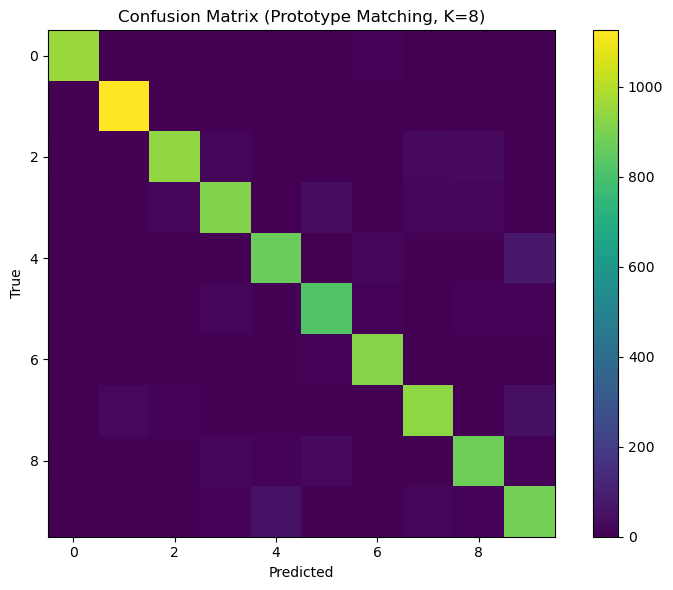

Saved confusion matrix to: C:\Users\vengg\Desktop\vip-digit-recognition\results\cm_proto_K8.png


In [97]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix (Prototype Matching, K={K})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()

cm_path = os.path.join(RESULTS_DIR, f"cm_proto_K{K}.png")
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved confusion matrix to:", cm_path)


Per-digit Accuracy

In [99]:
for d in range(10):
    acc_d = np.mean(y_pred[y_test == d] == d)
    print(f"Digit {d}: {acc_d:.3f}")


Digit 0: 0.974
Digit 1: 0.991
Digit 2: 0.911
Digit 3: 0.902
Digit 4: 0.884
Digit 5: 0.917
Digit 6: 0.962
Digit 7: 0.910
Digit 8: 0.898
Digit 9: 0.880


### Per-digit Performance Analysis

Digits with simple and distinctive shapes such as **1, 0, and 6**
achieve very high accuracy above 96%.

Digits such as **4, 8, and 9** show slightly lower accuracy due to
structural similarities and higher intra-class variation.
This limitation is expected in template matching approaches that do
not use learned feature hierarchies.

Overall, the system maintains consistent performance across all digits,
demonstrating robustness of the VIP preprocessing and prototype strategy.


Save Prototypes for Streamlit

In [101]:
proto_path = os.path.join(RESULTS_DIR, f"prototypes_K{K}.npz")

np.savez_compressed(
    proto_path,
    **{f"digit_{d}": prototypes[d] for d in range(10)}
)

print("Saved prototypes to:", proto_path)


Saved prototypes to: C:\Users\vengg\Desktop\vip-digit-recognition\results\prototypes_K8.npz


## 7. Summary of Results

The prototype-based digit recognition system achieved an overall accuracy of:

**92.37% (K = 8 prototypes per digit)**

Key observations:
- High accuracy for digits with distinct shapes (e.g., 1, 0, 6)
- Slightly lower accuracy for visually similar digits (e.g., 4, 8, 9)
- Consistent performance across all digits, with no class below 88%

These results demonstrate that classical VIP techniques can achieve strong
performance on handwritten digit recognition without deep learning.


## 8. Comparison with Baseline

To evaluate the benefit of using multiple prototypes, the proposed K=8
approach was compared against a simpler single-template baseline.


In [125]:
K_baseline = 1
proto_1 = build_prototypes(X_train_norm, y_train, K=K_baseline)

y_pred_1 = [predict_prototype(img, proto_1)[0] for img in X_test_norm[:2000]]
acc_1 = np.mean(y_pred_1 == y_test[:2000])

print(f"Baseline (K=1) accuracy on subset: {acc_1:.3f}")
print(f"Proposed (K=8) accuracy: 0.9237")


Digit 0: built 1 prototypes
Digit 1: built 1 prototypes
Digit 2: built 1 prototypes
Digit 3: built 1 prototypes
Digit 4: built 1 prototypes
Digit 5: built 1 prototypes
Digit 6: built 1 prototypes
Digit 7: built 1 prototypes
Digit 8: built 1 prototypes
Digit 9: built 1 prototypes
Baseline (K=1) accuracy on subset: 0.788
Proposed (K=8) accuracy: 0.9237


## 9. Limitations

Although the proposed system performs well, several limitations exist:

- Template matching struggles when digits are heavily connected
- Extreme handwriting styles may not match existing prototypes
- Segmentation errors can propagate to recognition errors in multi-digit images

These limitations motivate careful preprocessing and segmentation,
especially for real-world handwritten inputs.


## 10. Integration with Web Application

The trained prototypes were saved and reused in a Streamlit-based web application.
The web app supports:

- Uploading handwritten images
- Detecting one or more digits
- Visualizing digit segmentation
- Displaying recognition results in a user-friendly interface

This demonstrates the practical usability of the proposed VIP system.


## 11. Reproducibility

To reproduce the results:
1. Place MNIST IDX files in `data/mnist/`
2. Run this notebook from top to bottom
3. Generated prototypes are saved to `results/prototypes_K8.npz`
4. Launch the Streamlit app to perform real-time digit recognition

All experiments were conducted using Python and OpenCV without deep learning.


## 12. Conclusion

This project demonstrated that handwritten digit recognition can be effectively
implemented using classical Visual Information Processing techniques.

By combining VIP preprocessing with multi-prototype template matching,
the system achieved over **92% accuracy** on the MNIST dataset.
The approach avoids deep learning while remaining accurate, interpretable,
and computationally lightweight.

The resulting system was successfully deployed as an interactive web application,
highlighting the practical relevance of VIP methods in real-world scenarios.
